# Imports

In [1]:
import matplotlib.pyplot as plt 
import numpy as np
import pandas as pd

# Format data (Wt, 24h)

In [2]:
df_org = pd.read_excel("data/unformated/Daten_Label_24hWt.xlsx", sheet_name="formatted")
rows_unl = [i for i in range(len(df_org)) if i % 2 == 0]
rows_l = [i for i in range(len(df_org)) if i % 2 != 0]
df = df_org.drop(rows_l, axis=0)
df_l = df_org.drop(rows_unl, axis=0)

# add labeled values as new columns
df["exp2_22deg_l"] = df_l["exp2_22deg"].values
df["exp2_37deg_l"] = df_l["exp2_37deg"].values
df["exp4_22deg_l"] = df_l["exp4_22deg"].values
df["exp4_37deg_l"] = df_l["exp4_37deg"].values

# Preprocessing
## Relative values

In [3]:
cols = df.columns[1:]

for col in cols:
    exp = col.split("_")[0]
    exp_cols = [col for col in cols if "rel" not in col and exp in col]
    sum_exp = df[exp_cols].to_numpy().sum()
    abs_values = df[col].values
    rel_values = [val/sum_exp for val in abs_values]

    df[f"{col}_rel"] = rel_values

    # print("Experiment:", exp)
    # print("Experiment columns:", exp_cols)
    # print("Sum experiment:", sum_exp)
    # print("Column:", col)
    # print("Absolute values:", abs_values)
    # print("Relative values:", rel_values)
    # break
df

,compound,exp2_22deg,exp2_37deg,exp4_22deg,exp4_37deg,exp2_22deg_l,exp2_37deg_l,exp4_22deg_l,exp4_37deg_l,exp2_22deg_rel,exp2_37deg_rel,exp4_22deg_rel,exp4_37deg_rel,exp2_22deg_l_rel,exp2_37deg_l_rel,exp4_22deg_l_rel,exp4_37deg_l_rel
0,Cer_d18:0_16:1,0.455266,0.664672,4.361017,4.041854,0.590029,1.330840,1.751701,12.784263,0.001631,0.002381,0.001991,0.001845,2.113761e-03,0.004768,0.000800,0.005836
2,Cer_d18:1_16:0,0.008314,0.030973,0.213277,1.027376,0.000000,0.000000,0.000000,0.000000,0.000030,0.000111,0.000097,0.000469,0.000000e+00,0.000000,0.000000,0.000000
4,Cer_d18:0_16:0,0.845007,3.065323,7.673410,11.641499,0.769539,3.942692,2.768000,28.825347,0.003027,0.010981,0.003503,0.005314,2.756850e-03,0.014125,0.001263,0.013158
6,Cer_t18:1_16:0,1.484050,0.381282,11.028406,5.483669,0.765445,0.311419,3.767719,8.696305,0.005317,0.001366,0.005034,0.002503,2.742184e-03,0.001116,0.001720,0.003970
8,Cer_t18:0_16:0,0.714294,0.540984,8.950478,8.163473,0.638938,0.458556,3.743305,8.494877,0.002559,0.001938,0.004086,0.003726,2.288977e-03,0.001643,0.001709,0.003878
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
170,GIPC(t18:0/h26:1),0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000
172,GIPC(t18:1/h26:0),6.039552,6.282832,79.768858,68.016927,0.000000,0.000000,0.671180,0.469128,0.021637,0.022508,0.036412,0.031047,0.000000e+00,0.000000,0.000306,0.000214
174,GIPC_t18:1_h28:1,0.102296,0.114532,3.261995,2.773375,0.000194,0.001501,0.005100,0.005913,0.000366,0.000410,0.001489,0.001266,6.946643e-07,0.000005,0.000002,0.000003
176,GIPC_t18:0_h28:1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000


In [9]:
df.filter(regex="exp2").filter(regex="rel").to_numpy().sum()

np.float64(1.0000000000000002)

In [10]:
df.filter(regex="exp4").filter(regex="rel").to_numpy().sum()

np.float64(1.0)

## Means

In [6]:
df["mean_22deg"] = df[["exp2_22deg_rel", "exp4_22deg_rel"]].mean(axis=1)
df["mean_37deg"] = df[["exp2_37deg_rel", "exp4_37deg_rel"]].mean(axis=1)
df["mean_22deg_l"] = df[["exp2_22deg_l_rel", "exp4_22deg_l_rel"]].mean(axis=1)
df["mean_37deg_l"] = df[["exp2_37deg_l_rel", "exp4_37deg_l_rel"]].mean(axis=1)
df

,compound,exp2_22deg,exp2_37deg,exp4_22deg,exp4_37deg,exp2_22deg_l,exp2_37deg_l,exp4_22deg_l,exp4_37deg_l,exp2_22deg_rel,...,exp4_22deg_rel,exp4_37deg_rel,exp2_22deg_l_rel,exp2_37deg_l_rel,exp4_22deg_l_rel,exp4_37deg_l_rel,mean_22deg,mean_37deg,mean_22deg_l,mean_37deg_l
0,Cer_d18:0_16:1,0.455266,0.664672,4.361017,4.041854,0.590029,1.330840,1.751701,12.784263,0.001631,...,0.001991,0.001845,2.113761e-03,0.004768,0.000800,0.005836,0.001811,0.002113,1.456676e-03,0.005302
2,Cer_d18:1_16:0,0.008314,0.030973,0.213277,1.027376,0.000000,0.000000,0.000000,0.000000,0.000030,...,0.000097,0.000469,0.000000e+00,0.000000,0.000000,0.000000,0.000064,0.000290,0.000000e+00,0.000000
4,Cer_d18:0_16:0,0.845007,3.065323,7.673410,11.641499,0.769539,3.942692,2.768000,28.825347,0.003027,...,0.003503,0.005314,2.756850e-03,0.014125,0.001263,0.013158,0.003265,0.008148,2.010174e-03,0.013641
6,Cer_t18:1_16:0,1.484050,0.381282,11.028406,5.483669,0.765445,0.311419,3.767719,8.696305,0.005317,...,0.005034,0.002503,2.742184e-03,0.001116,0.001720,0.003970,0.005175,0.001935,2.231009e-03,0.002543
8,Cer_t18:0_16:0,0.714294,0.540984,8.950478,8.163473,0.638938,0.458556,3.743305,8.494877,0.002559,...,0.004086,0.003726,2.288977e-03,0.001643,0.001709,0.003878,0.003322,0.002832,1.998834e-03,0.002760
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
170,GIPC(t18:0/h26:1),0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000
172,GIPC(t18:1/h26:0),6.039552,6.282832,79.768858,68.016927,0.000000,0.000000,0.671180,0.469128,0.021637,...,0.036412,0.031047,0.000000e+00,0.000000,0.000306,0.000214,0.029024,0.026778,1.531854e-04,0.000107
174,GIPC_t18:1_h28:1,0.102296,0.114532,3.261995,2.773375,0.000194,0.001501,0.005100,0.005913,0.000366,...,0.001489,0.001266,6.946643e-07,0.000005,0.000002,0.000003,0.000928,0.000838,1.511255e-06,0.000004
176,GIPC_t18:0_h28:1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000


## Degree of labeling

In [7]:
df["sum_22deg"] = df[["mean_22deg", "mean_22deg_l"]].sum(axis=1)
df["sum_37deg"] = df[["mean_37deg", "mean_37deg_l"]].sum(axis=1)
df["dol_22deg"] = df["mean_22deg_l"] /  df["sum_22deg"]
df["dol_37deg"] = df["mean_37deg_l"] /  df["sum_37deg"]

# df.to_csv("data/formated/wt_24h.csv", index=False)
df

,compound,exp2_22deg,exp2_37deg,exp4_22deg,exp4_37deg,exp2_22deg_l,exp2_37deg_l,exp4_22deg_l,exp4_37deg_l,exp2_22deg_rel,...,exp4_22deg_l_rel,exp4_37deg_l_rel,mean_22deg,mean_37deg,mean_22deg_l,mean_37deg_l,sum_22deg,sum_37deg,dol_22deg,dol_37deg
0,Cer_d18:0_16:1,0.455266,0.664672,4.361017,4.041854,0.590029,1.330840,1.751701,12.784263,0.001631,...,0.000800,0.005836,0.001811,0.002113,1.456676e-03,0.005302,0.003267,0.007415,0.445809,0.715017
2,Cer_d18:1_16:0,0.008314,0.030973,0.213277,1.027376,0.000000,0.000000,0.000000,0.000000,0.000030,...,0.000000,0.000000,0.000064,0.000290,0.000000e+00,0.000000,0.000064,0.000290,0.000000,0.000000
4,Cer_d18:0_16:0,0.845007,3.065323,7.673410,11.641499,0.769539,3.942692,2.768000,28.825347,0.003027,...,0.001263,0.013158,0.003265,0.008148,2.010174e-03,0.013641,0.005275,0.021789,0.381068,0.626062
6,Cer_t18:1_16:0,1.484050,0.381282,11.028406,5.483669,0.765445,0.311419,3.767719,8.696305,0.005317,...,0.001720,0.003970,0.005175,0.001935,2.231009e-03,0.002543,0.007406,0.004477,0.301230,0.567911
8,Cer_t18:0_16:0,0.714294,0.540984,8.950478,8.163473,0.638938,0.458556,3.743305,8.494877,0.002559,...,0.001709,0.003878,0.003322,0.002832,1.998834e-03,0.002760,0.005321,0.005592,0.375643,0.493562
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
170,GIPC(t18:0/h26:1),0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,NaN,NaN
172,GIPC(t18:1/h26:0),6.039552,6.282832,79.768858,68.016927,0.000000,0.000000,0.671180,0.469128,0.021637,...,0.000306,0.000214,0.029024,0.026778,1.531854e-04,0.000107,0.029177,0.026885,0.005250,0.003983
174,GIPC_t18:1_h28:1,0.102296,0.114532,3.261995,2.773375,0.000194,0.001501,0.005100,0.005913,0.000366,...,0.000002,0.000003,0.000928,0.000838,1.511255e-06,0.000004,0.000929,0.000842,0.001626,0.004795
176,GIPC_t18:0_h28:1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,NaN,NaN


# Normalisation

# Degree of labeling

Text(0.5, 0.98, 'Distribution of labeling degree')

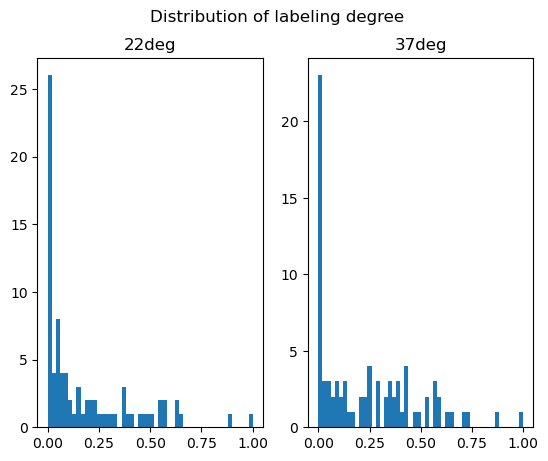

In [ ]:
fig, axs = plt.subplots(1, 2)

for i, title in zip([0, 1], ["dol_22deg", "dol_37deg"]):
    axs[i].hist(df[title].values, bins=50)
    axs[i].set_title(f"{title.split("_")[1]}")

plt.suptitle("Distribution of labeling degree")